# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python) 

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [59]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

In [60]:
# cargar archivos
orders = pd.read_csv("https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv")
catalog = pd.read_csv("https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv")
marketing = pd.read_csv("https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv")

In [61]:
# explorar datasets
orders.head()

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


In [62]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB


In [63]:
orders.describe()

,cantidad,precio_unitario,monto_descuento,monto_total
count,25050.000000,25050.000000,25050.000000,2.510000e+04
mean,7.092735,259.305549,4.500798,2.072680e+03
std,296.277003,138.726461,5.223010,9.894995e+04
min,-2.000000,20.030000,0.000000,-4.926500e+02
25%,1.000000,138.377500,0.000000,1.805075e+02
50%,2.000000,258.715000,0.000000,3.417500e+02
75%,2.000000,380.332500,10.000000,5.185800e+02
max,20000.000000,499.960000,15.000000,8.840200e+06


Al explorar el dataset Orders:
- Es necesario cambiar el tipo de dato del campo fecha_hora_pedido a fecha
- Existen valores negativos en el campo cantidad
- Existen valores nulos en pais, dispositivo, fuente_referencia, nombre_producto, categoria_producto, cantidad, precio_unitario y monto descuento.
- Se debe verificar si es posible completar el campo categoria_producto a partir de nombre_producto desde catalog.
- Se debe verificar si es posible completar el campo precio_unitario desde el campo costo_unitario del dataset catalog y a su vez el campo cantidad a partir de éste y el monto_total.

In [64]:
catalog.head(10)

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"
5,Sneakers-Urban-42,Moda,17.21,Greene-Smith
6,Jacket-Winter-M,Moda,189.31,Mcmillan-Rhodes


In [65]:
catalog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


In [66]:
catalog.describe()

,costo_unitario
count,7.000000
mean,102.252857
std,111.011563
min,10.120000
25%,16.905000
50%,25.210000
75%,182.975000
max,280.680000


Al explorar el dataset Catalog, no se encuentran novedades en los campos.

In [67]:
marketing.head()

,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40


In [68]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB


In [69]:
marketing.describe()

,gasto
count,1620.00000
mean,1772.74292
std,734.43294
min,501.11000
25%,1128.03000
50%,1782.42500
75%,2420.68500
max,2999.36000


Al explorar el dataset marketing se determina que:
- El campo canal tiene valores nulos que pueden ser completados a partir del campo id_campaña.
- Es necesario cambiar el tipo de dato del campo fecha a tipo fecha.

---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas 

---

In [70]:
# Visualizamos los registros que tienen valores negativos que debemos corregir
orders[(orders['cantidad'] < 0) | (orders['monto_total'] < 0)]

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
266,order_266,user_7011,2025-03-13,NaN,desktop,paid_search,Phone-Pro-128GB,Electronica,-2.0,101.31,10.0,-192.62
267,order_267,user_1087,2025-05-07,NaN,desktop,social,Phone-Pro-128GB,Electronica,-1.0,43.50,5.0,-38.50
268,order_268,user_84,2025-02-19,NaN,desktop,organic,Phone-Pro-128GB,Electronica,-1.0,497.65,5.0,-492.65
269,order_269,user_3323,2025-05-25,NaN,desktop,paid_search,Phone-Pro-128GB,Electronica,-1.0,423.53,0.0,-423.53


In [71]:
# Visualizamos los registros que tienen valores ceros inválidos que debemos corregir
orders[(orders['cantidad'] == 0) | (orders['precio_unitario'] == 0) | (orders['monto_total'] == 0)]

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total


In [72]:
# Verificamos los pedidos únicos
orders['id_pedido'].nunique()

25000

In [73]:
# Verificamos si existen duplicados
orders.duplicated().sum()

100

In [74]:
# Eliminamos los duplicados
registros_antes = len(orders)
duplicados_detectados = orders.duplicated().sum()
orders = orders.drop_duplicates().reset_index(drop=True)
duplicados_eliminados = registros_antes - len(orders)
print('Registros iniciales:', registros_antes)
print('Duplicados detectados:', duplicados_detectados)
print('Duplicados eliminados:', duplicados_eliminados)
print('Registros finales:', len(orders))

Registros iniciales: 25100
Duplicados detectados: 100
Duplicados eliminados: 100
Registros finales: 25000


In [75]:
# Verificamos si se puede completar categoria_producto utilzando nombre_producto
orders['categoria_producto'].isna().groupby(orders['nombre_producto']).sum()

nombre_producto
Blender-XL-Red           3
Jacket-Winter-M         10
Laptop-Gaming-16GB       4
Phone-Pro-128GB          3
Sneakers-Urban-42       19
Tablet-Standard-64GB     5
Vacuum-Pro-Black         6
Name: categoria_producto, dtype: int64

De acuerdo al análisis exploratorio en la siguiente función se procede a:
- Convertir la variable fecha_hora_pedido a tipo fecha
- Convertir los valores nulos detectados en cantidad y monto_total a valores válidos. Se observó que el monto_total era negativo en los mismos registros que cantidad, el cálculo era correcto, el valor negativo no, por lo que se convertirán estos valores en positivos
- No se detectaron valores cero en variables como cantidad, precio_unitario, monto_total.
- En cuanto a columna categoría_productos que tiene 80 registros faltantes, estos presentan un patrón asociado a nombre_producto, una variable observada. Además, la tabla catalog contiene la correspondencia entre producto y categoría, por lo que al menos 50 valores faltantes pueden recuperarse mediante nombre_producto. Por esta razón, se utiliza una imputación basada en una fuente de referencia confiable.

In [76]:
def limpiar_datos(df, cols_fecha, cols_negativos, cols_ceros, catalog): 
    reporte = {}
# 1. Convertir fechas
    reporte['fechas'] = {}
    for col in cols_fecha:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        reporte['fechas'][col] = {
                'valores_invalidos': df[col].isna().sum()}

# 2. Corregir valores negativos
    reporte['negativos'] = {}
    for col in cols_negativos:
        negativos = (df[col] < 0).sum()
        df.loc[df[col] < 0, col] = (df.loc[df[col] < 0, col].abs())
        reporte['negativos'][col] = negativos

# 3. Corregir ceros inválidos
    reporte['ceros'] = {}
    for col in cols_ceros:
        ceros = (df[col] == 0).sum()
        df.loc[df[col] == 0, col] = pd.NA
        reporte['ceros'][col] = ceros
    
# 4. Completar categorías desde el catálogo
    faltantes_antes = (df['categoria_producto'].isna().sum())
    mapa_categorias = (catalog.set_index('nombre_producto')
        ['categoria_producto'])
    df['categoria_producto'] = (df['categoria_producto']
        .fillna(df['nombre_producto'].map(mapa_categorias)))
    faltantes_despues = (df['categoria_producto'].isna().sum())
    reporte['categorias'] = {'faltantes_antes': faltantes_antes,
            'completadas': (faltantes_antes - faltantes_despues),
            'faltantes_despues': faltantes_despues}
    return df, reporte

In [77]:
orders, reporte_orders = limpiar_datos(
    orders,
    cols_fecha=['fecha_hora_pedido'],
    cols_negativos=['cantidad', 'monto_total'],
    cols_ceros=['cantidad', 'precio_unitario', 'monto_total'],
    catalog=catalog
)
reporte_orders

{'fechas': {'fecha_hora_pedido': {'valores_invalidos': 0}},
 'negativos': {'cantidad': 4, 'monto_total': 4},
 'ceros': {'cantidad': 0, 'precio_unitario': 0, 'monto_total': 0},
 'categorias': {'faltantes_antes': 80,
  'completadas': 50,
  'faltantes_despues': 30}}

In [78]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           25000 non-null  object        
 1   id_usuario          25000 non-null  object        
 2   fecha_hora_pedido   25000 non-null  datetime64[ns]
 3   pais                24700 non-null  object        
 4   dispositivo         24980 non-null  object        
 5   fuente_referencia   24970 non-null  object        
 6   nombre_producto     24970 non-null  object        
 7   categoria_producto  24970 non-null  object        
 8   cantidad            24950 non-null  object        
 9   precio_unitario     24950 non-null  object        
 10  monto_descuento     24950 non-null  float64       
 11  monto_total         25000 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(10)
memory usage: 2.3+ MB


Una vez realizada una limpieza inicial de los datos, verificamos si las variables categóricas son imputables.
Conocemos que tenemos 300 valores faltantes en la variable país, 20 en la variable dispositivo, por lo que agrupamos cada una por id_usuario para verificar si un usuario tiene un país único desde el que realiza el pedido, un dispositivo único por el que se conecta.

In [79]:
def analizar_imputables(df, columnas, clave='id_usuario'):
    resultados = {}
    for col in columnas:
        faltantes = df[df[col].isna()].copy()
        valores_usuario = (df.groupby(clave)[col].nunique())
        faltantes['num_valores'] = (faltantes[clave].map(valores_usuario))
        conteo = (faltantes['num_valores'].value_counts().sort_index())
        resultados[col] = {
            'faltantes': len(faltantes),
            'imputables': (faltantes['num_valores'] == 1).sum(),
            'multiples_valores': (faltantes['num_valores'] > 1).sum(),
            'sin_informacion': (faltantes['num_valores'] == 0).sum()
        }
    return pd.DataFrame(resultados).T

In [80]:
resultado = analizar_imputables(
    orders,['pais', 'dispositivo'])
print(resultado)

             faltantes  imputables  multiples_valores  sin_informacion
pais               300         195                 86               19
dispositivo         20          18                  0                2


In [81]:
# Imputar variable únicamente cuando el usuario tiene un solo país conocido
# desde donde realizó el pedido o un solo dispositivo desde el que se conectó.
def imputar_por_usuario(df, columnas):    
    resultados = {}
    for col in columnas:
        faltantes_antes = df[col].isna().sum()
        valores_usuario = (df.groupby('id_usuario')[col]
            .agg(['nunique', 'first'])        )
        valores_unicos = valores_usuario.loc[
            valores_usuario['nunique'] == 1,'first']
        df[col] = df[col].fillna(df['id_usuario'].map(valores_unicos))
        faltantes_despues = df[col].isna().sum()
        resultados[col] = {
            'faltantes_antes': faltantes_antes,
            'imputados': faltantes_antes - faltantes_despues,
            'faltantes_despues': faltantes_despues}
    return df, resultados

In [82]:
orders, resultados_imputacion = imputar_por_usuario(
    orders,
    columnas=['pais', 'dispositivo']
)
print(resultados_imputacion)

{'pais': {'faltantes_antes': 300, 'imputados': 195, 'faltantes_despues': 105}, 'dispositivo': {'faltantes_antes': 20, 'imputados': 18, 'faltantes_despues': 2}}


Se identificaron 300 registros con valores faltantes en la columna país y 20 en dispositivo. Se analizó la información disponible agrupando por id_usuario para determinar si el país podía inferirse de forma confiable. 
- Para país, en 195 registros, el usuario presentaba un único país desde el que realizó sus pedidos, por lo que se imputó dicho valor. En 86 registros, el usuario presentaba dos países diferentes, por lo que no fue posible determinar cuál correspondía al registro faltante. Los 19 registros restantes pertenecían a usuarios sin ningún país registrado. Estos 105 valores se conservaron como faltantes.
- Para dispositivo, en 18 registros, el usuario presenta un único dispositivo desde el que se conecta, por lo que se imputó dicho valor, 2 registros pertenecían a usuarios sin ningún dispositivo registrado, estos 2 valores se conservaron como faltantes.
- Los registros conservados como faltantes no fueron imputados para evitar introducir información no sustentada por los datos

In [83]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           25000 non-null  object        
 1   id_usuario          25000 non-null  object        
 2   fecha_hora_pedido   25000 non-null  datetime64[ns]
 3   pais                24895 non-null  object        
 4   dispositivo         24998 non-null  object        
 5   fuente_referencia   24970 non-null  object        
 6   nombre_producto     24970 non-null  object        
 7   categoria_producto  24970 non-null  object        
 8   cantidad            24950 non-null  object        
 9   precio_unitario     24950 non-null  object        
 10  monto_descuento     24950 non-null  float64       
 11  monto_total         25000 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(10)
memory usage: 2.3+ MB


In [84]:
# Se convierten cols numericas al formato correcto
cols_monto = ['cantidad', 'precio_unitario', 'monto_descuento', 'monto_total']
orders[cols_monto] = orders[cols_monto].apply(pd.to_numeric, errors='coerce')

# Se verifica consistencia en el monto_total
orders['verificacion_monto'] = (orders['cantidad'] * orders['precio_unitario']
    - orders['monto_descuento'])
comparacion = orders[
    orders['verificacion_monto'].notna()
].copy()
comparacion['diferencia'] = (
    comparacion['monto_total'] -
    comparacion['verificacion_monto']
)
# Se verifica diferencia en los valores
print("Total registros:", len(comparacion))
print("Diferencias de 0:", 
      (comparacion['diferencia'].round(2) == 0).sum())
print("Diferencias de ±0.01:", 
      (comparacion['diferencia'].round(2).abs() == 0.01).sum())
print("Diferencias mayores a ±0.01:", 
      (comparacion['diferencia'].round(2).abs() > 0.01).sum())

# Eliminar columna auxiliar
orders.drop(columns='verificacion_monto', inplace=True)

Total registros: 24950
Diferencias de 0: 18717
Diferencias de ±0.01: 6233
Diferencias mayores a ±0.01: 0


Se realizó una validación del campo monto_total, calculando nuevamente una variable mediante la fórmula ((cantidad × precio_unitario) − monto_descuento). De los 24.950 registros analizados (no se compararon los registros nulos de verificacion_monto), 18.717 presentan coincidencia exacta y 6.233 presentan una diferencia de ±0,01, atribuible al redondeo de valores monetarios. No se encontraron registros con diferencias superiores a $0,01, por lo que se considera que el campo monto_total es consistente.

In [85]:
# Se verifican valores nulos en los campos de Orders
print(orders.isna().sum())
#print()
#print(orders.isna().mean().sort_values(ascending=False))

id_pedido               0
id_usuario              0
fecha_hora_pedido       0
pais                  105
dispositivo             2
fuente_referencia      30
nombre_producto        30
categoria_producto     30
cantidad               50
precio_unitario        50
monto_descuento        50
monto_total             0
dtype: int64


In [86]:
# Se calcula min, max y mediana para cantidad, precio_unitario, 
# monto_descuento y monto_total para verificar consistencia de datos
#en estas variables
completos = orders[
    orders[cols_monto].notna().all(axis=1)].copy()
resumen_productos = completos.groupby('nombre_producto')[cols_monto].agg(
    ['min', 'max', 'median'])
resumen_productos

cantidad                 precio_unitario          \
                          min      max median             min     max   
nombre_producto                                                         
Blender-XL-Red            1.0      2.0    2.0           20.06  499.94   
Jacket-Winter-M           1.0      2.0    2.0           20.06  499.93   
Laptop-Gaming-16GB        1.0  20000.0    2.0           20.24  499.95   
Phone-Pro-128GB           1.0      2.0    2.0           20.08  499.86   
Sneakers-Urban-42         1.0      2.0    1.0           20.11  499.91   
Tablet-Standard-64GB      1.0      2.0    2.0           20.03  499.89   
Vacuum-Pro-Black          1.0      2.0    2.0           20.37  499.96   

                              monto_descuento              monto_total  \
                       median             min   max median         min   
nombre_producto                                                          
Blender-XL-Red        256.335             0.0  15.0    5.0        5.83   
Jacket-Winter-M       259.195             0.0  15.0    5.0        9.43   
Laptop-Gaming-16GB    261.160             0.0  15.0    5.0        5.24   
Phone-Pro-128GB       261.570             0.0  15.0    0.0        6.64   
Sneakers-Urban-42     256.180             0.0  15.0    0.0        7.38   
Tablet-Standard-64GB  255.010             0.0  15.0    0.0        5.42   
Vacuum-Pro-Black      261.685             0.0  15.0    0.0        5.64   

                                           
                             max   median  
nombre_producto                            
Blender-XL-Red            999.89  339.035  
Jacket-Winter-M           999.59  337.670  
Laptop-Gaming-16GB    8840200.00  349.485  
Phone-Pro-128GB           999.38  345.750  
Sneakers-Urban-42         999.26  334.880  
Tablet-Standard-64GB      999.24  337.290  
Vacuum-Pro-Black          999.27  346.260

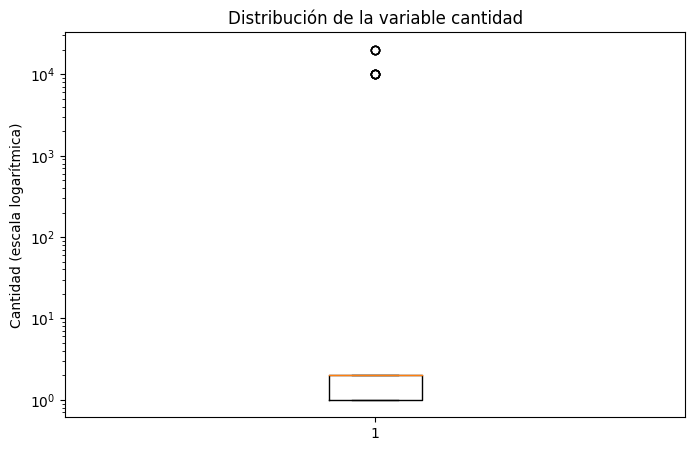

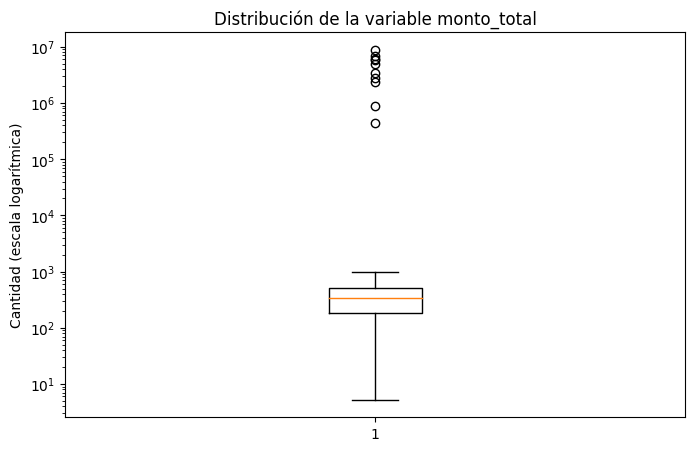

In [87]:
# Se observan valores máximos atípicos en cantidad y
# monto_total vamos a examinarlos con boxplot

cols_num2= ['cantidad', 'monto_total']
for col in cols_num2:
    plt.figure(figsize=(8, 5))
    plt.boxplot(orders[col].dropna())
    plt.yscale('log')
    plt.title(f'Distribución de la variable {col}')
    plt.ylabel('Cantidad (escala logarítmica)')
    plt.show()

In [88]:
# Calculamos el IQR para determinar el límite superior de estas variables

limites_superiores = {}
for col in cols_num2:
    Q1 = orders[col].quantile(0.25)
    Q3 = orders[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    limites_superiores[col] = limite_superior
    print(f"IQR para {col}:", IQR)
    print(f"Límite superior para {col}:", limite_superior)


IQR para cantidad: 1.0
Límite superior para cantidad: 3.5
IQR para monto_total: 337.8075
Límite superior para monto_total: 1025.29125


In [89]:
# Una vez calculado el IQR, contemos cuantos valores de cantidad y
# monto_total son outliers
for col in cols_num2:
    print(f'\n--- Outliers en {col} ---')
    print(orders[orders[col] > limites_superiores[col]
            ][col].value_counts().sort_index())


--- Outliers en cantidad ---
10000.0    6
20000.0    4
Name: cantidad, dtype: int64

--- Outliers en monto_total ---
431400.0     1
876900.0     1
2381500.0    1
2805500.0    1
3369300.0    1
4903500.0    1
5817000.0    1
5953200.0    1
6966200.0    1
8840200.0    1
Name: monto_total, dtype: int64


Podemos determinar que estos valores atípicos (10 en cantidad y 10 en monto_total) son errores, debido a que el modelo de negocio de Rappi está diseñado bajo el concepto de on-demand delivery (entregas inmediatas de consumo personal o familiar). Por lo tanto, las restricciones de volumen e inventario son universales y se deben a tres pilares globales de la empresa:
1. **El modelo "Última Milla" (Last-Mile Delivery)**
   En todos los mercados, el servicio depende de repartidores independientes que se movilizan principalmente en motocicletas y bicicletas. La mochila estándar de Rappi tiene una capacidad física limitada. Ningún país contempla el envío masivo que requiera camiones o fletes pesados a través de la aplicación tradicional.
   
3. **Términos y Condiciones unificados**
   En sus contratos de uso globales se especifica que:
   - La plataforma se reserva el derecho de cancelar o limitar cantidades si detecta que la orden no corresponde a un consumo minorista normal.
   - Existen topes de valor comercial máximo asegurado por pedido.
   - Las pasarelas de pago de Rappi y los bancos emisores bloquean automáticamente transacciones de montos tan elevados por políticas de seguridad contra el lavado de dinero y clonación de tarjetas.
     
4. **Integración de Software con Aliados**
- El sistema tecnológico de Rappi en toda Latinoamérica bloquea la opción de añadir cantidades exorbitantes en el carrito de compras.
- Las tiendas configuran alertas de quiebre de stock e inhabilitan productos automáticamente si un usuario intenta agotar el inventario físico de una sucursal en un solo segundo.
- Las tiendas de tecnología aliadas en Rappi solo mantienen un inventario de exhibición o de contingencia en sus sucursales físicas (generalmente de 2 a 5 unidades por tienda para artículos de alta rotación).

In [90]:
# Verifiquemos si los registros que tienen los valores atípicos en cantidad
# tienen consistencia en el cálculo del monto_total

outliers = orders[
    (orders[cols_num2] > pd.Series(limites_superiores)).any(axis=1)]
outliers

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
3521,order_3521,user_5812,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,43.14,0.0,431400.0
3522,order_3522,user_3575,2025-03-29,Argentina,desktop,social,Laptop-Gaming-16GB,Electronica,10000.0,280.55,0.0,2805500.0
3586,order_3586,user_3380,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,490.35,0.0,4903500.0
3643,order_3643,user_4440,2025-01-07,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,10000.0,238.15,0.0,2381500.0
3656,order_3656,user_884,2025-01-01,Argentina,mobile,organic,Laptop-Gaming-16GB,Electronica,20000.0,297.66,0.0,5953200.0
3668,order_3668,user_7270,2025-06-24,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,20000.0,348.31,0.0,6966200.0
3689,order_3689,user_6566,2025-06-16,mexico,desktop,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,87.69,0.0,876900.0
3722,order_3722,user_4723,2025-05-09,Argentina,mobile,paid_search,Laptop-Gaming-16GB,Electronica,20000.0,442.01,0.0,8840200.0
3726,order_3726,user_2536,2025-02-12,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,20000.0,290.85,0.0,5817000.0
3748,order_3748,user_7096,2025-02-23,Mexico,desktop,organic,Laptop-Gaming-16GB,Electronica,10000.0,336.93,0.0,3369300.0


Los 10 registros problemáticos son:
- 6 con cantidad = 10.000
- 4 con cantidad = 20.000
- todos son Laptop-Gaming-16GB
- el precio unitario está dentro del rango normal
- el descuento es 0
- monto_total fue calculado correctamente a partir de la cantidad errónea por lo tanto también es erróneo.
- Incluso si fueran 10 o 20 laptops sería imposible para un local realizar la entrega inmediata de esa cantidad, siendo lo más lógico reemplazar por 1 o 2.

In [91]:
#Corregimos los outliers
orders['cantidad_corregida'] = orders['cantidad'].replace({
    10000.0: 1.0,
    20000.0: 2.0})

#Calculamos el nuevo monto
orders['monto_total_corregido'] = np.where(
    orders['precio_unitario'].notna(),
    orders['cantidad_corregida'] * orders['precio_unitario'] - orders['monto_descuento'],
    orders['monto_total'])

# Verificamos cambios
orders[orders['cantidad'].isin([10000, 20000])][
    ['nombre_producto', 'cantidad', 'cantidad_corregida',
        'precio_unitario', 'monto_descuento', 'monto_total',
        'monto_total_corregido']]

,nombre_producto,cantidad,cantidad_corregida,precio_unitario,monto_descuento,monto_total,monto_total_corregido
3521,Laptop-Gaming-16GB,10000.0,1.0,43.14,0.0,431400.0,43.14
3522,Laptop-Gaming-16GB,10000.0,1.0,280.55,0.0,2805500.0,280.55
3586,Laptop-Gaming-16GB,10000.0,1.0,490.35,0.0,4903500.0,490.35
3643,Laptop-Gaming-16GB,10000.0,1.0,238.15,0.0,2381500.0,238.15
3656,Laptop-Gaming-16GB,20000.0,2.0,297.66,0.0,5953200.0,595.32
3668,Laptop-Gaming-16GB,20000.0,2.0,348.31,0.0,6966200.0,696.62
3689,Laptop-Gaming-16GB,10000.0,1.0,87.69,0.0,876900.0,87.69
3722,Laptop-Gaming-16GB,20000.0,2.0,442.01,0.0,8840200.0,884.02
3726,Laptop-Gaming-16GB,20000.0,2.0,290.85,0.0,5817000.0,581.70
3748,Laptop-Gaming-16GB,10000.0,1.0,336.93,0.0,3369300.0,336.93


In [92]:
# Se verifica si los valores nulos de cantidad, precio_unitario y 
# monto_descuento, se encuentran en los mismos registros o si hay alguna
# oportunidad de imputar
orders.loc[orders[['cantidad', 'precio_unitario', 'monto_descuento']]
    .isna().all(axis=1),['nombre_producto', 'categoria_producto', 
    'cantidad', 'precio_unitario', 'monto_descuento', 'monto_total']]

,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
74,Sneakers-Urban-42,Moda,NaN,NaN,NaN,595.85
75,Sneakers-Urban-42,Moda,NaN,NaN,NaN,458.15
76,Laptop-Gaming-16GB,Electrónica,NaN,NaN,NaN,319.75
77,Vacuum-Pro-Black,Hogar,NaN,NaN,NaN,227.55
78,Phone-Pro-128GB,Electrónica,NaN,NaN,NaN,432.39
79,Sneakers-Urban-42,Moda,NaN,NaN,NaN,527.15
80,Vacuum-Pro-Black,Hogar,NaN,NaN,NaN,711.18
81,Tablet-Standard-64GB,Electrónica,NaN,NaN,NaN,41.08
82,Sneakers-Urban-42,Moda,NaN,NaN,NaN,431.55
83,Sneakers-Urban-42,Moda,NaN,NaN,NaN,279.35


La variable cantidad tiene valores faltantes en los mismos registros que las variables precio_unitario y monto_descuento, por lo tanto no se puede imputar a partir del cálculo monto_total= cantidad * precio_unitario -monto_descuento

In [93]:
# Agrupamos por nombre_producto
orders[orders['cantidad_corregida'].isna()].groupby('nombre_producto').size().sort_values(ascending=False)

nombre_producto
Sneakers-Urban-42       19
Jacket-Winter-M         10
Vacuum-Pro-Black         6
Tablet-Standard-64GB     5
Laptop-Gaming-16GB       4
Blender-XL-Red           3
Phone-Pro-128GB          3
dtype: int64

In [94]:
# Después de corregir los outliers, veamos que valores toma cantidad
orders.groupby(
    ['nombre_producto', 'cantidad_corregida']
).size()

nombre_producto       cantidad_corregida
Blender-XL-Red        1.0                   2073
                      2.0                   2103
Jacket-Winter-M       1.0                   2076
                      2.0                   2090
Laptop-Gaming-16GB    1.0                   1344
                      2.0                   1434
Phone-Pro-128GB       1.0                   1329
                      2.0                   1408
Sneakers-Urban-42     1.0                   2086
                      2.0                   2043
Tablet-Standard-64GB  1.0                   1375
                      2.0                   1389
Vacuum-Pro-Black      1.0                   2056
                      2.0                   2114
dtype: int64

In [95]:
# Veamos los valores min, max y mediana para cada producto
orders[
    (orders['cantidad_corregida'].notna())].groupby('nombre_producto')['cantidad_corregida'].agg(
    ['count', 'min', 'max', 'median'])

,count,min,max,median
nombre_producto,,,,
Blender-XL-Red,4176,1.0,2.0,2.0
Jacket-Winter-M,4166,1.0,2.0,2.0
Laptop-Gaming-16GB,2778,1.0,2.0,2.0
Phone-Pro-128GB,2737,1.0,2.0,2.0
Sneakers-Urban-42,4129,1.0,2.0,1.0
Tablet-Standard-64GB,2764,1.0,2.0,2.0
Vacuum-Pro-Black,4170,1.0,2.0,2.0


In [96]:
# Con el resultado anterior podemos considerar una 
# imputación basada en la mediana por producto

faltantes_cantidad = orders['cantidad_corregida'].isna().sum()
faltantes = orders['cantidad_corregida'].isna()
medianas_cantidad = (
    orders[orders['cantidad_corregida'].between(1, 2)]
    .groupby('nombre_producto')['cantidad_corregida']
    .median())
orders['cantidad_corregida'] = orders['cantidad_corregida'].fillna(
    orders['nombre_producto'].map(medianas_cantidad))
nuevos_faltantes = orders['cantidad_corregida'].isna().sum()
print('Faltantes en cantidad:', faltantes_cantidad)
print('Faltantes de cantidad completados:', (faltantes_cantidad - nuevos_faltantes))


Faltantes en cantidad: 50
Faltantes de cantidad completados: 50


In [97]:
# Verificamos si hay alguna relación que pueda ayudarnos a imputar
# precio_unitario y monto_descuento
orders.loc[faltantes,
    ['id_pedido', 'nombre_producto', 'cantidad_corregida', 'precio_unitario',
    'monto_descuento', 'monto_total']
]

,id_pedido,nombre_producto,cantidad_corregida,precio_unitario,monto_descuento,monto_total
74,order_74,Sneakers-Urban-42,1.0,NaN,NaN,595.85
75,order_75,Sneakers-Urban-42,1.0,NaN,NaN,458.15
76,order_76,Laptop-Gaming-16GB,2.0,NaN,NaN,319.75
77,order_77,Vacuum-Pro-Black,2.0,NaN,NaN,227.55
78,order_78,Phone-Pro-128GB,2.0,NaN,NaN,432.39
79,order_79,Sneakers-Urban-42,1.0,NaN,NaN,527.15
80,order_80,Vacuum-Pro-Black,2.0,NaN,NaN,711.18
81,order_81,Tablet-Standard-64GB,2.0,NaN,NaN,41.08
82,order_82,Sneakers-Urban-42,1.0,NaN,NaN,431.55
83,order_83,Sneakers-Urban-42,1.0,NaN,NaN,279.35


No se pudo encontrar un patrón para imputar precio_unitario y monto_descuento

In [98]:
# Verificamos las columnas categóricas de orders
cols_categoricas= ['pais', 'dispositivo', 'fuente_referencia', 'nombre_producto', 'categoria_producto']
for i in cols_categoricas:
    print(i, orders[i].value_counts())
    print()

pais Mexico       7542
Colombia     7539
Argentina    7328
mexico        864
colombia      824
argentina     798
Name: pais, dtype: int64

dispositivo desktop    12721
mobile     12277
Name: dispositivo, dtype: int64

fuente_referencia social         8402
organic        8288
paid_search    8280
Name: fuente_referencia, dtype: int64

nombre_producto Blender-XL-Red          4179
Jacket-Winter-M         4176
Vacuum-Pro-Black        4176
Sneakers-Urban-42       4148
Laptop-Gaming-16GB      2782
Tablet-Standard-64GB    2769
Phone-Pro-128GB         2740
Name: nombre_producto, dtype: int64

categoria_producto Hogar          8355
Moda           8324
Electronica    8279
Electrónica      12
Name: categoria_producto, dtype: int64



- Es necesario corregir los valores únicos de la variable pais, ya que los nombres de los países están en minusculas y en otros tienen la primera letra en mayúsculas.
- De igual manera es necesario corregir los nombres de las categorías ya que electronica no está estandarizada.

In [99]:
# 1. Estandarizar país en orders
orders['pais'] = orders['pais'].str.strip().str.capitalize()
# 2. Estandarizar categoría en orders
orders['categoria_producto'] = orders['categoria_producto'].replace('Electronica', 'Electrónica')

In [100]:
# Verificamos que los nombres de los países esten estandarizados
orders['pais'].value_counts()

Mexico       8406
Colombia     8363
Argentina    8126
Name: pais, dtype: int64

In [101]:
# Verificamos que los nombres de las categorías estén estandarizados
orders['categoria_producto'].value_counts()

Hogar          8355
Moda           8324
Electrónica    8291
Name: categoria_producto, dtype: int64

In [102]:
orders[cols_categoricas].isna().sum().sort_values(ascending=False)

pais                  105
fuente_referencia      30
nombre_producto        30
categoria_producto     30
dispositivo             2
dtype: int64

In [103]:
for col in cols_categoricas:
    orders[col]=orders[col].fillna('unknown')

In [104]:
# Verificamos las columnas categóricas de catalog
print(catalog.isna().sum())
print()
print(catalog.isna().mean().sort_values(ascending=False))


nombre_producto       0
categoria_producto    0
costo_unitario        0
proveedor             0
dtype: int64

nombre_producto       0.0
categoria_producto    0.0
costo_unitario        0.0
proveedor             0.0
dtype: float64


In [105]:
cols_categoricas= ['nombre_producto', 'categoria_producto','proveedor']
for i in cols_categoricas:
    print(i, catalog[i].value_counts())
    print()

nombre_producto Jacket-Winter-M         1
Laptop-Gaming-16GB      1
Sneakers-Urban-42       1
Blender-XL-Red          1
Vacuum-Pro-Black        1
Tablet-Standard-64GB    1
Phone-Pro-128GB         1
Name: nombre_producto, dtype: int64

categoria_producto Electrónica    3
Moda           2
Hogar          2
Name: categoria_producto, dtype: int64

proveedor King Ltd                   1
Long-Reid                  1
Fuller, Pena and Myers     1
Rivera, Carr and Finley    1
Mcmillan-Rhodes            1
Bowers LLC                 1
Greene-Smith               1
Name: proveedor, dtype: int64



Analizando más a detalle las variables categóricas de catalog, se confirma que no tienen novedades.

In [106]:
# Verificamos las columnas categóricas de marketing
print(marketing.isna().sum())
print()
print(marketing.isna().mean().sort_values(ascending=False))

fecha           0
pais            0
id_campaña      0
canal         101
gasto           0
dtype: int64

canal         0.062346
fecha         0.000000
pais          0.000000
id_campaña    0.000000
gasto         0.000000
dtype: float64


In [107]:
cols_categoricas= ['pais', 'id_campaña', 'canal']
for i in cols_categoricas:
    print(i, marketing[i].value_counts())
    print()

pais Colombia     540
Argentina    540
Mexico       540
Name: pais, dtype: int64

id_campaña social_Colombia          180
paid_search_Argentina    180
social_Argentina         180
paid_search_Mexico       180
organic_Mexico           180
social_Mexico            180
organic_Colombia         180
paid_search_Colombia     180
organic_Argentina        180
Name: id_campaña, dtype: int64

canal paid_search    507
organic        506
social         506
Name: canal, dtype: int64



La variable canal tiene valores faltantes que pueden ser llenadas desde id_campaña, ya que en esta variable están unidos el canal y el país.

In [108]:
# Completar canal desde id_campaña
canal_calculado = (marketing['id_campaña'].str.rsplit('_', n=1).str[0])
marketing['canal'] = (marketing['canal'].fillna(canal_calculado))

In [109]:
#Verificamos que los valores faltantes de canal en marketing esten imputados
marketing['canal'].value_counts()

organic        540
social         540
paid_search    540
Name: canal, dtype: int64

---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [52]:
orders.columns.tolist()

['id_pedido',
 'id_usuario',
 'fecha_hora_pedido',
 'pais',
 'dispositivo',
 'fuente_referencia',
 'nombre_producto',
 'categoria_producto',
 'cantidad',
 'precio_unitario',
 'monto_descuento',
 'monto_total',
 'cantidad_corregida',
 'monto_total_corregido']

In [53]:
orders_copy = orders.copy()
orders = orders_copy.drop(columns=['cantidad', 'monto_total']
).rename(columns={
    'cantidad_corregida': 'cantidad',
    'monto_total_corregido': 'monto_total'})
orders.head()

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,precio_unitario,monto_descuento,cantidad,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,332.69,0.0,2.0,665.38
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electrónica,176.86,5.0,1.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,102.99,10.0,2.0,195.98
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electrónica,257.87,15.0,1.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,336.28,0.0,1.0,336.28


In [54]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           25000 non-null  object        
 1   id_usuario          25000 non-null  object        
 2   fecha_hora_pedido   25000 non-null  datetime64[ns]
 3   pais                25000 non-null  object        
 4   dispositivo         25000 non-null  object        
 5   fuente_referencia   25000 non-null  object        
 6   nombre_producto     25000 non-null  object        
 7   categoria_producto  25000 non-null  object        
 8   precio_unitario     24950 non-null  float64       
 9   monto_descuento     24950 non-null  float64       
 10  cantidad            25000 non-null  float64       
 11  monto_total         25000 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(7)
memory usage: 2.3+ MB


In [55]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False, sep=';', decimal=',')
catalog.to_csv('catalog_clean.csv', index=False, sep=';', decimal=',')
marketing.to_csv('marketing_clean.csv', index=False, sep=';', decimal=',')

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)? 
- ¿Cuál es el costo total? 
- ¿Cuánto se ha invertido en marketing? 
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden? 
- ¿Cuál es la cantidad promedio de productos por orden? 
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal? 

In [56]:
# tu código aquí
numero_ventas = orders['monto_total'].count()
print("Número de ventas:", numero_ventas)
ingreso_total = orders['monto_total'].sum()  
print(f"Ingreso total: ${ingreso_total:,.2f}")

Número de ventas: 25000
Ingreso total: $9,649,292.14


In [57]:
costo = orders.merge(
    catalog[['nombre_producto', 'costo_unitario']],
    on='nombre_producto', 
    how='left')
costo['costo_total'] = costo['cantidad'] * costo['costo_unitario']
costo_total = costo['costo_total'].sum()
print(f"Costo total: ${costo_total:,.2f}")

Costo total: $3,840,779.62


In [58]:
inversion_marketing = marketing['gasto'].sum()
print(f"Inversión total en marketing: ${inversion_marketing:,.2f}")

Inversión total en marketing: $2,871,843.53


In [59]:
profit = ingreso_total-costo_total-inversion_marketing
print(f"Profit: ${profit:,.2f}")

Profit: $2,936,668.99


In [60]:
margen_ganancia = (profit / ingreso_total)
print(f"Margen: ${margen_ganancia:,.2%}")

Margen: $30.43%


In [62]:
roi_marketing = (profit / inversion_marketing)
print(f"ROI de Marketing: ${roi_marketing:,.2f}")

ROI de Marketing: $1.02


In [63]:
ticket_promedio = ingreso_total/numero_ventas
print(f"Ticket promedio: ${ticket_promedio:,.2f}")

Ticket promedio: $385.97


In [64]:
cantidad_total = orders['cantidad'].sum()
cantidad_promedio_por_orden = cantidad_total / numero_ventas
print(f"Cantidad promedio de productos por orden: {cantidad_promedio_por_orden:.2f}")

Cantidad promedio de productos por orden: 1.51


In [65]:
ventas_producto = orders.groupby('nombre_producto')['cantidad'].sum().sort_values(ascending=False)
for nombre_producto, cantidad in ventas_producto.items():
    print(f"{nombre_producto}: {cantidad}")

Vacuum-Pro-Black: 6296.0
Blender-XL-Red: 6285.0
Jacket-Winter-M: 6276.0
Sneakers-Urban-42: 6191.0
Laptop-Gaming-16GB: 4220.0
Tablet-Standard-64GB: 4163.0
Phone-Pro-128GB: 4151.0
unknown: 45.0


In [67]:
ingresos_categoria = orders.groupby('categoria_producto')['monto_total'].sum().sort_values(ascending=False)
for categoria_producto, monto_total in ingresos_categoria.items():
    print(f"{categoria_producto}: ${monto_total:,.2f}")

Hogar: $3,237,571.12
Electrónica: $3,213,960.67
Moda: $3,185,497.76
unknown: $12,262.59


In [68]:
ingreso_pais = orders.groupby('pais')['monto_total'].sum().sort_values(ascending=False)
for pais, monto_total in ingreso_pais.items():
    print(f"{pais}: ${monto_total:,.2f}")

Mexico: $3,242,720.86
Colombia: $3,204,231.35
Argentina: $3,163,738.09
unknown: $38,601.84


In [69]:
gasto_por_canal = (marketing.groupby('canal')['gasto'].sum().sort_values(ascending=False))
for canal, gasto in gasto_por_canal.items():
    print(f"{canal}: ${gasto:,.2f}")

social: $976,818.37
organic: $972,650.96
paid_search: $922,374.20


---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [2]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [3]:
# Explorar tabla events
# =========================

query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()


,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [4]:
query = '''
SELECT COUNT(*) AS total_registros
FROM events;
'''

total = pd.read_sql(query, con=engine)

total

,total_registros
0,120000


In [5]:
query_events = '''

SELECT
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios
FROM events
GROUP BY nombre_evento
ORDER BY usuarios DESC;

'''
events = pd.read_sql(query_events, con=engine)
events

,nombre_evento,usuarios
0,first_visit,7796
1,add_to_cart,7634
2,select_item,7582
3,begin_checkout,7208
4,add_payment_info,6250
5,purchase,6240


In [6]:

# PARTE 1: Totales del funnel

# ======================
query_totals = '''

WITH first_visit AS (
    SELECT
        id_usuario
    FROM events
    WHERE nombre_evento = 'first_visit'
    GROUP BY id_usuario
),
select_item AS (
    SELECT
        id_usuario
    FROM events
    WHERE nombre_evento = 'select_item'
    AND id_usuario in (select id_usuario from first_visit)
    GROUP BY id_usuario
),
add_to_cart AS (
    SELECT
        id_usuario
    FROM events 
    WHERE nombre_evento = 'add_to_cart'
    AND id_usuario in (select id_usuario from select_item)
    GROUP BY id_usuario
),
begin_checkout AS (
    SELECT
        id_usuario
    FROM events
    WHERE nombre_evento = 'begin_checkout'
    AND id_usuario in (select id_usuario from add_to_cart)
    GROUP BY id_usuario
),
add_payment_info AS (
    SELECT
        id_usuario
    FROM events
    WHERE nombre_evento = 'add_payment_info'
    AND id_usuario in (select id_usuario from begin_checkout)
    GROUP BY id_usuario
),
purchase AS (
    SELECT
        id_usuario
    FROM events
    WHERE nombre_evento = 'purchase'
    AND id_usuario in (select id_usuario from add_payment_info)
    GROUP BY id_usuario
)

SELECT
    COUNT(DISTINCT fv.id_usuario) AS usuarios_first_visit,
    COUNT(DISTINCT si.id_usuario) AS usuarios_select_item,
    COUNT(DISTINCT atc.id_usuario) AS usuarios_add_to_cart,
    COUNT(DISTINCT bc.id_usuario) AS usuarios_begin_checkout,
    COUNT(DISTINCT api.id_usuario) AS usuarios_add_payment_info,
    COUNT(DISTINCT p.id_usuario) AS usuarios_purchase
FROM first_visit fv
LEFT JOIN select_item si
    ON fv.id_usuario = si.id_usuario
LEFT JOIN add_to_cart atc
    ON si.id_usuario = atc.id_usuario
LEFT JOIN begin_checkout bc
    ON atc.id_usuario = bc.id_usuario
LEFT JOIN add_payment_info api 
    ON bc.id_usuario = api.id_usuario
LEFT JOIN purchase p 
    ON api.id_usuario = p.id_usuario
ORDER BY usuarios_first_visit DESC;
'''

totals = pd.read_sql(query_totals, con=engine)
totals


,usuarios_first_visit,usuarios_select_item,usuarios_add_to_cart,usuarios_begin_checkout,usuarios_add_payment_info,usuarios_purchase
0,7796,7393,7052,6364,4967,3857


¿Cuántos usuarios llegan a cada etapa del funnel?
- First_visit 7796
- Select_item 7393
- Add_to_cart 7052
- Begin_chekout 6364
- Add_payment_info 4967
- Purchase 3857

In [7]:
# PARTE 2: Conversiones
# ======================
totals.to_sql(
    'totals_temp',
    con=engine,
    index=False,
    if_exists='replace'
)
query_conversion = '''
SELECT
    usuarios_select_item * 100.0 /
        NULLIF(usuarios_first_visit, 0) AS conversion_select_item,
    usuarios_add_to_cart * 100.0 /
        NULLIF(usuarios_select_item, 0) AS conversion_add_to_cart,
    usuarios_begin_checkout * 100.0 /
        NULLIF(usuarios_add_to_cart, 0) AS conversion_begin_checkout,
    usuarios_add_payment_info * 100.0 /
        NULLIF(usuarios_begin_checkout, 0) AS conversion_add_payment_info,
    usuarios_purchase * 100.0 /
        NULLIF(usuarios_add_payment_info, 0) AS conversion_purchase,
    usuarios_purchase * 100.0 /
        NULLIF(usuarios_first_visit, 0) AS conversion_first_to_purchase
FROM totals_temp
ORDER BY conversion_purchase DESC;

'''
conversion = pd.read_sql(query_conversion, con=engine)
conversion.round(2)

,conversion_select_item,conversion_add_to_cart,conversion_begin_checkout,conversion_add_payment_info,conversion_purchase,conversion_first_to_purchase
0,94.83,95.39,90.24,78.05,77.65,49.47


El principal punto de fricción del funnel se encuentra en la fase final del proceso de compra (add_payment_info-->purchase), se pierde el 22.35% de los usuarios. Esto sugiere revisar posibles problemas relacionados con la confirmación del pago, errores en la transacción, costos adicionales inesperados o abandono antes de finalizar el pedido.
Tasa de conversión final: 49,47%.

---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users` 
- `user_activity` 

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [8]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [9]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity
'''

user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(12)


,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1
3,user_0,2025-02-26,28,0
4,user_1,2025-01-14,7,0
5,user_1,2025-01-21,14,0
6,user_1,2025-01-28,21,1
7,user_1,2025-02-04,28,0
8,user_2,2025-03-19,7,0
9,user_2,2025-03-26,14,1


In [13]:
query_calculo_semanas = '''
SELECT
    u.id_usuario,
    u.fecha_registro,
    ua.fecha_actividad,
    (ua.fecha_actividad::date - u.fecha_registro::date) / 7 AS semanas
FROM users u, user_activity ua
WHERE u.id_usuario = ua.id_usuario AND u.id_usuario='user_0';
'''
calculo_semanas = pd.read_sql(query_calculo_semanas, con=engine)
calculo_semanas.head(12)

,id_usuario,fecha_registro,fecha_actividad,semanas
0,user_0,2025-01-29,2025-02-05,1
1,user_0,2025-01-29,2025-02-12,2
2,user_0,2025-01-29,2025-02-19,3
3,user_0,2025-01-29,2025-02-26,4


In [15]:
# Retención por cohortes
# ======================
query_cohort_retention_final = '''
WITH usuarios_cohorte AS (
    SELECT
        id_usuario,
        DATE_TRUNC('month', CAST(fecha_registro AS DATE)) AS mes_cohorte
    FROM users
),
retencion AS (
    SELECT
        u.mes_cohorte,
        -- Usuarios iniciales de la cohorte
        COUNT(DISTINCT u.id_usuario) AS usuarios_iniciales,
        -- Usuarios retenidos por semana
        COUNT(DISTINCT CASE
            WHEN ua.dias_despues_registro = 7 AND ua.activo = 1 THEN ua.id_usuario END) AS retenido_w1,
        COUNT(DISTINCT CASE
            WHEN ua.dias_despues_registro = 14 AND ua.activo = 1 THEN ua.id_usuario END) AS retenido_w2,
        COUNT(DISTINCT CASE
            WHEN ua.dias_despues_registro = 21 AND ua.activo = 1 THEN ua.id_usuario END) AS retenido_w3,
        COUNT(DISTINCT CASE 
            WHEN ua.dias_despues_registro = 28 AND ua.activo = 1 THEN ua.id_usuario END) AS retenido_w4
    FROM usuarios_cohorte u
    LEFT JOIN user_activity ua
        ON u.id_usuario = ua.id_usuario
    GROUP BY u.mes_cohorte
)
SELECT
    TO_CHAR(mes_cohorte, 'Mon YYYY') AS cohorte,
    usuarios_iniciales,
    retenido_w1,
    retenido_w2,
    retenido_w3,
    retenido_w4,
    -- Porcentaje de retención
    ROUND(retenido_w1 * 100.0 / NULLIF(usuarios_iniciales, 0), 2) AS pct_w1,
    ROUND(retenido_w2 * 100.0 / NULLIF(usuarios_iniciales, 0), 2) AS pct_w2,
    ROUND(retenido_w3 * 100.0 / NULLIF(usuarios_iniciales, 0), 2) AS pct_w3,
    ROUND(retenido_w4 * 100.0 / NULLIF(usuarios_iniciales, 0), 2) AS pct_w4
FROM retencion;

'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,cohorte,usuarios_iniciales,retenido_w1,retenido_w2,retenido_w3,retenido_w4,pct_w1,pct_w2,pct_w3,pct_w4
0,Jan 2025,1627,697,668,656,671,42.84,41.06,40.32,41.24
1,Feb 2025,1444,611,609,635,575,42.31,42.17,43.98,39.82
2,Mar 2025,1636,677,705,690,673,41.38,43.09,42.18,41.14
3,Apr 2025,1606,680,697,663,652,42.34,43.40,41.28,40.60
4,May 2025,1687,695,676,706,679,41.20,40.07,41.85,40.25


Insight de retención por cohortes

La retención de usuarios se mantiene relativamente estable durante las primeras cuatro semanas, ubicándose aproximadamente entre 40% y 43% en todas las cohortes analizadas. En general, no se observa una caída pronunciada de la retención, lo que indica que una proporción importante de los usuarios continúa regresando durante el primer mes. Sin embargo, la estabilidad alrededor del 40% también evidencia una oportunidad para fortalecer las estrategias de engagement y reactivación, especialmente entre los usuarios que dejan de estar activos después de la primera semana.

Insight accionable: implementar campañas de reactivación y comunicación personalizada entre la segunda y cuarta semana posteriores al registro, con el objetivo de convertir a los usuarios que aún no regresan en usuarios recurrentes y elevar la retención por encima del nivel actual del 40%.

---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado** 
4. **Interpretar el resultado**  

---
Hipótesis estadística
   - **H₀ (Hipótesis nula):** La tasa de conversión es igual en ambas variantes control y tratamiento.
   - **H₁ (Hipótesis alternativa):** La tasa de conversión es diferente entre las variantes control y tratamiento.
   
**Test estadístico:** z-test  
**Nivel de significancia alpha:** 0.05

In [41]:
# tu código aquí
df = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')

In [42]:
df.head()

,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_usuario       10000 non-null  object 
 1   variante         10000 non-null  object 
 2   convirtio        10000 non-null  int64  
 3   dispositivo      10000 non-null  object 
 4   pais             10000 non-null  object 
 5   duracion_sesion  10000 non-null  float64
 6   timestamp        10000 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 547.0+ KB


In [44]:
# Explorar variables categóricas y cómo se distribuyen
col_categoricas=['variante', 'convirtio', 'dispositivo', 'pais']
print("\nConteo de categorías:")
for col in col_categoricas:
    print(f"Columna {col}")
    print(df[col].value_counts())
    print()


Conteo de categorías:
Columna variante
tratamiento    5035
control        4965
Name: variante, dtype: int64

Columna convirtio
0    8401
1    1599
Name: convirtio, dtype: int64

Columna dispositivo
desktop    5042
mobile     4958
Name: dispositivo, dtype: int64

Columna pais
Mexico       3405
Argentina    3317
Colombia     3278
Name: pais, dtype: int64



In [65]:
# Calculamos los usuarios convertidos por variante
conversiones = df.groupby('variante')['convirtio'].sum()

# Calculamos los usuarios totales por variante
totales = df.groupby('variante')['convirtio'].count()

print("Usuarios convertidos por variante:\n", conversiones)
print("\nTotal de usuarios por variante:\n", totales)

Usuarios convertidos por variante:
 variante
control        779
tratamiento    820
Name: convirtio, dtype: int64

Total de usuarios por variante:
 variante
control        4965
tratamiento    5035
Name: convirtio, dtype: int64


In [60]:
# Calculamos las tasas de conversión por variante
tasa_control = conversiones[0] / totales[0]
tasa_tratamiento = conversiones[1] / totales[1]
print(f'Tasa de conversión control: {tasa_control:.2%}')
print(f'Tasa de conversión tratamiento: {tasa_tratamiento:.2%}')

Tasa de conversión control: 15.69%
Tasa de conversión tratamiento: 16.29%


In [61]:
# Aplicar prueba
exitos = [conversiones['control'], conversiones['tratamiento']]
observaciones = [totales['control'], totales['tratamiento']]
z_stat, p_value = proportions_ztest(exitos, observaciones)

# Visualizar resultados
print(f"Estadístico z: {z_stat}")
print(f"Valor p: {p_value}")

Estadístico z: -0.8132782986429474
Valor p: 0.41605851639119995


In [64]:
# Comparamos con el umbral 
alpha = 0.05
if p_value < alpha:
    print("Rechazamos la hipótesis nula, hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula, no hay evidencia suficiente de una diferencia")

No rechazamos la hipótesis nula, no hay evidencia suficiente de una diferencia



El z-test obtuvo un estadístico z = -0,813 y un valor p = 0,416, por lo que no se encontró evidencia estadísticamente significativa de que la variante tratamiento mejore la tasa de conversión.

Aunque la variante tratamiento alcanzó una tasa de conversión de 16,29 %, frente al 15,69 % de la variante control, lo que representa una diferencia observada de 0,60 puntos porcentuales, sin embargo, los resultados del z-test no permiten concluir que la nueva interfaz genere una mejora real en la conversión.

Por ello, no se recomendaría implementar el cambio basándose en estos resultados. Antes de tomar una decisión, sería conveniente evaluar la relevancia económica de la mejora observada y, de ser posible, realizar un experimento con mayor capacidad para detectar diferencias entre las variantes.

---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión. 

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

**Resumen ejecutivo**

**Hallazgos clave**

📈 Crecimiento comercial positivo

Los ingresos alcanzan $9,6 M acumulados a junio y presentan un crecimiento de 11,14% YoY, evidenciando una evolución comercial favorable a pesar de las fluctuaciones mensuales.

🌎 Desempeño equilibrado entre mercados

México, Colombia y Argentina generan niveles muy similares tanto de ingresos como de profit, por lo que el negocio no muestra una dependencia significativa de un único mercado.

🏠 Hogar lidera la generación de valor

La categoría Hogar registra el mayor profit, sin embargo, la diferencia no es suficientemente grande como para hablar de una concentración extrema de rentabilidad.

⚠️ La rentabilidad presenta diferencias importantes a nivel de producto

El desempeño cambia considerablemente entre productos. Vacuum-Pro-Black y Sneakers-Urban-42 destacan por su contribución al profit, mientras que Laptop-Gaming-16GB y Jacket-Winter-M presentan resultados negativos.

💰 El riesgo de ventas bajo costo se concentra en determinados productos

Se realizó un análisis de las unidades vendidas a precios menores a su costo unitario y se encontraron los siguientes porcentajes:

Laptop-Gaming-16GB: 53%
Jacket-Winter-M: 36%
Blender-XL-Red: 33%
Tablet-Standard-64GB: 1%

Esto convierte a Laptop-Gaming-16GB en el principal foco de revisión de pricing y rentabilidad.

**Métricas Principales**
Las principales métricas monitoreadas en el dashboard fueron:

- Ingreso Total: valor total generado por las ventas de productos.
- Inversión en Marketing: gasto total en publicidad.
- Profit: Utilidad comercial del negocio
- Cantidad Promedio: número promedio de productos vendidos por pedido.
- Ticket Promedio: valor promedio por pedido.
- Margen %: Utilidad comercial obtenida en porcentaje
- MoM %: variación porcentual de los ingresos respecto al mes anterior.

**Insights accionables**

**1. Priorizar la revisión de Laptop-Gaming-16GB**

Es el caso más crítico porque combina:
profit negativo + alta frecuencia de ventas bajo costo + elevada pérdida potencial.
Con $298.826,16 de pérdida potencial asociada a ventas bajo costo, este producto debería ser el primer candidato para revisar precios, descuentos y promociones.

**2. Revisar la estructura de precios de Jacket-Winter-M**

Aunque su impacto es menor que el de Laptop, 36% de sus ventas se realizan por debajo del costo y acumula una pérdida potencial de $188 K.

**3. Investigar precios de Blender-XL-Red**

Blender presenta una situación diferente: tiene 33% de ventas bajo costo, pero mantiene un profit ligeramente positivo de $23 K. Esto indica que tener ventas bajo costo no implica necesariamente que el producto sea deficitario; las ventas a precios superiores al costo pueden estar compensando la exposición.

**4. El crecimiento comercial no garantiza rentabilidad homogénea**

El negocio mantiene una trayectoria acumulada positiva, pero el análisis por producto demuestra que el crecimiento agregado puede ocultar pérdidas importantes en determinados productos, siendo necesario monitorear el profit por producto junto con volumen, precio y costo, en lugar de evaluar únicamente las ventas.

**5. No priorizar acciones geográficas**

Dado que México, Colombia y Argentina presentan resultados muy similares, no hay evidencia de que un mercado específico sea el origen principal del problema de rentabilidad. La oportunidad está principalmente en el nivel de producto y pricing, no en redistribuir la estrategia geográfica.

**Recomendaciones estratégicas**

🔴 Prioridad 1 — Corregir pérdidas por pricing

Realizar una auditoría de los productos, identificando todos los pedidos donde:

Precio de venta < Costo unitario

Separar las causas entre descuento, promoción, error de precio, error de costo o problema de datos.

🟠 Prioridad 2 — Implementar control de margen

Crear una regla de negocio que impida o requiera autorización para vender por debajo del costo, salvo que exista una estrategia explícita —por ejemplo, liquidación— que justifique la pérdida.


🟢 Prioridad 3 — Potenciar productos rentables

Utilizar los productos con alto profit como referencia para identificar qué características están asociadas a una mejor generación de valor: precio, costo, volumen, descuento y marketing.

El objetivo no sería simplemente vender más, sino escalar aquellos productos capaces de convertir ventas en profit.


---

## 🚀 Entrega Final

Comparte el acceso a tu Dashboard para revisión.   
Puedes entregar el Dashboard utilizando **Power BI o Tableau**.

Incluye **uno de los siguientes**:

- 🔗 Link público del dashboard publicado en **Power BI Service o Tableau Public / Tableau Cloud**
- 🔗 Link de **Google Drive o OneDrive** con el archivo del proyecto (`.pbix`) y los 3 csvs limpios.


### 📎 Enlace del Dashboard

# (Pega aquí tu link)
https://drive.google.com/drive/folders/1Zn6JLIBzMwjY3eHkxWQtdkoUn6fZFtUW?usp=sharing